In [ ]:
from pathlib import Path
from shutil import rmtree
from json import dumps
from typing import Literal
from pickle import Pickler
from gzip import open as gz_open
from joblib import Memory

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder, minmax_scale
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.metrics import make_scorer, f1_score


RANDOM_STATE = 42
RANDOM_RNG = np.random.default_rng(42)
VIF_THRESHOLD = 10.0

# Data

In [2]:
def get_vif_removal_features(threshold: float) -> frozenset[str]:
    vif_values = Path("../datasense/dataset/vif_values.csv")
    vif_values = pd.read_csv(vif_values)
    vif_values = vif_values[vif_values["vif"] >= threshold]
    return frozenset(vif_values["feature"])


def get_transformer(data: pd.DataFrame, vif_threshold: float = VIF_THRESHOLD):
    number_selector = make_column_selector(dtype_include="number")
    bool_selector = make_column_selector(dtype_include="bool")
    first_transformer = make_column_transformer(
        (OneHotEncoder(sparse_output=False), ["device_type"]),
        ("passthrough", number_selector),
        ("passthrough", bool_selector),
        remainder="drop",
        verbose_feature_names_out=False,
    )
    _ = first_transformer.fit_transform(data)
    feature_names = first_transformer.get_feature_names_out()
    vif_removal = get_vif_removal_features(vif_threshold)
    vif_indexes = [i for i, ft in enumerate(feature_names) if ft in vif_removal]
    second_transformer = make_column_transformer(
        ("drop", vif_indexes),
        remainder="passthrough",
        verbose_feature_names_out=False,
    )
    return make_pipeline(first_transformer, second_transformer)


def prepare_experiment(
    target: Literal["binary", "condensed", "granular"],
    overwrite: bool = False,
):
    experiment = {}
    dataset_path = Path("../datasense/dataset/")
    for split in ["train", "test"]:
        split_data = dataset_path / f"datasense_1sec_{split}.parquet"
        split_data = pd.read_parquet(split_data)
        if target == "binary":
            y_split = split_data["label1"]
        elif target == "condensed":
            y_split = split_data["label2"]
        elif target == "granular":
            y_split = split_data["label4"]
        else:
            raise ValueError("Unknown target")
        experiment[split] = (split_data, y_split)
    X_train, y_train = experiment["train"]
    experiment["classes"] = sorted(y_train.unique())
    experiment["transformer"] = get_transformer(X_train)
    results_dir = Path(f"results/decision_tree__{target}")
    if results_dir.is_dir():
        if overwrite:
            rmtree(results_dir, ignore_errors=True)
        else:
            raise RuntimeError(
                "Experiment already executed and overwrite set to False"
            )
    results_dir.mkdir(exist_ok=True, parents=True)
    cache_dir = results_dir / ".cache"
    cache_dir.mkdir()
    experiment["results_dir"] = results_dir
    experiment["cache_dir"] = Memory(location=cache_dir, verbose=0)
    return experiment

In [3]:
experiment = prepare_experiment(target="granular", overwrite=True)

X_train, y_train = experiment["train"]
class_names = experiment["classes"]
num_classes = len(class_names)
X_test, y_test = experiment["test"]
results_dir = experiment["results_dir"]
cache_dir = experiment["cache_dir"]

# Experiment

## Training pipe

In [ ]:
model = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=RANDOM_RNG,
)

In [5]:
train_pipe = Pipeline(
    steps=[
        ("transformer", experiment["transformer"]),
        ("model", model),
    ],
    memory=cache_dir,
    verbose=False,
)

## Grid seach cross-validation

In [6]:
param_grid = {
    "model__criterion": ["gini", "entropy"],
    # `min_samples_leaf` : offer a bit more of regularization for the training
    "model__min_samples_leaf": [3, 5, 7],
    # `max_depth`      : is too restrictive a measure of complexity
    # `max_leaf_nodes` : represents the level of partitioning of the training data
    # `max_leaf_nodes` : too many partitions can mean overfitting
    "model__max_leaf_nodes": [800, 1600, 3200, None],
}

In [7]:
grid = GridSearchCV(
    estimator=train_pipe,
    param_grid=param_grid,
    scoring=(
        "f1_macro" if num_classes > 2
        else make_scorer(f1_score, pos_label="attack")
    ),
    n_jobs=4,
    refit=True,
    cv=4,
    verbose=3,
    return_train_score=True,
)

grid.fit(X_train, y_train)

trained_pipe = grid.best_estimator_
trained_model = trained_pipe["model"]

Fitting 4 folds for each of 24 candidates, totalling 96 fits
[CV 1/4] END model__criterion=gini, model__max_leaf_nodes=800, model__min_samples_leaf=3;, score=(train=0.727, test=0.682) total time=   5.2s
[CV 4/4] END model__criterion=gini, model__max_leaf_nodes=800, model__min_samples_leaf=3;, score=(train=0.718, test=0.675) total time=   5.2s
[CV 3/4] END model__criterion=gini, model__max_leaf_nodes=800, model__min_samples_leaf=3;, score=(train=0.719, test=0.673) total time=   5.1s
[CV 2/4] END model__criterion=gini, model__max_leaf_nodes=800, model__min_samples_leaf=3;, score=(train=0.707, test=0.664) total time=   5.4s
[CV 1/4] END model__criterion=gini, model__max_leaf_nodes=800, model__min_samples_leaf=5;, score=(train=0.707, test=0.672) total time=   3.6s
[CV 4/4] END model__criterion=gini, model__max_leaf_nodes=800, model__min_samples_leaf=5;, score=(train=0.704, test=0.666) total time=   3.8s
[CV 3/4] END model__criterion=gini, model__max_leaf_nodes=800, model__min_samples_leaf=

## Cross-validation results

In [8]:
cv_results = pd.DataFrame(grid.cv_results_)
cv_results.sort_values(by="rank_test_score", inplace=True)
cv_results.to_csv(results_dir / "train_cv_results.csv", index=False)
cv_results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__criterion,param_model__max_leaf_nodes,param_model__min_samples_leaf,params,split0_test_score,split1_test_score,...,split3_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,mean_train_score,std_train_score
21,3.067659,0.069969,0.304444,0.030365,entropy,None,3,"{'model__criterion': 'entropy', 'model__max_le...",0.726465,0.727021,...,0.721062,0.722685,0.004413,1,0.835509,0.833485,0.834347,0.830532,0.833468,0.001841
9,3.356085,0.112488,0.336036,0.075726,gini,None,3,"{'model__criterion': 'gini', 'model__max_leaf_...",0.719987,0.718572,...,0.719588,0.717643,0.003056,2,0.836112,0.832044,0.829486,0.832784,0.832607,0.002365
22,3.179338,0.136266,0.309237,0.056631,entropy,None,5,"{'model__criterion': 'entropy', 'model__max_le...",0.702189,0.700878,...,0.699648,0.699520,0.002563,3,0.788227,0.785700,0.784897,0.786891,0.786429,0.001258
6,4.907708,0.350398,0.460234,0.077721,gini,3200,3,"{'model__criterion': 'gini', 'model__max_leaf_...",0.697914,0.695884,...,0.698324,0.695711,0.003025,4,0.779461,0.777059,0.778856,0.781486,0.779215,0.001580
10,3.313406,0.071738,0.320632,0.013731,gini,None,5,"{'model__criterion': 'gini', 'model__max_leaf_...",0.701803,0.693958,...,0.694674,0.694644,0.004849,5,0.784695,0.785153,0.784173,0.785339,0.784840,0.000451
18,4.009468,0.133837,0.339173,0.054774,entropy,3200,3,"{'model__criterion': 'entropy', 'model__max_le...",0.688389,0.690101,...,0.686282,0.686791,0.002877,6,0.770130,0.769106,0.767593,0.768375,0.768801,0.000935
7,5.026078,0.191852,0.415413,0.062061,gini,3200,5,"{'model__criterion': 'gini', 'model__max_leaf_...",0.690446,0.679868,...,0.683669,0.682396,0.005453,7,0.759928,0.759803,0.760371,0.760150,0.760063,0.000217
23,2.928928,0.176060,0.273994,0.036614,entropy,None,7,"{'model__criterion': 'entropy', 'model__max_le...",0.684370,0.683948,...,0.680867,0.681628,0.002827,8,0.756244,0.753499,0.751788,0.754671,0.754051,0.001629
3,4.183510,0.269165,0.382860,0.016414,gini,1600,3,"{'model__criterion': 'gini', 'model__max_leaf_...",0.686852,0.682057,...,0.677049,0.680209,0.004635,9,0.747875,0.741819,0.741120,0.741527,0.743085,0.002777
19,4.055794,0.048081,0.301392,0.014030,entropy,3200,5,"{'model__criterion': 'entropy', 'model__max_le...",0.684430,0.679345,...,0.676434,0.678393,0.004077,10,0.754953,0.751447,0.749859,0.753107,0.752341,0.001895


## Feature importance

In [9]:
feature_names = trained_pipe["transformer"].get_feature_names_out()
feature_importances = pd.DataFrame({
    "feature": feature_names,
    "importance": trained_pipe["model"].feature_importances_,
})
feature_importances.sort_values(
    by="importance", ascending=False,
    ignore_index=True, inplace=True,
)
feature_importances["importance_norm"] = minmax_scale(feature_importances["importance"])
feature_importances.to_csv(results_dir / "feature_importances.csv", index=False)

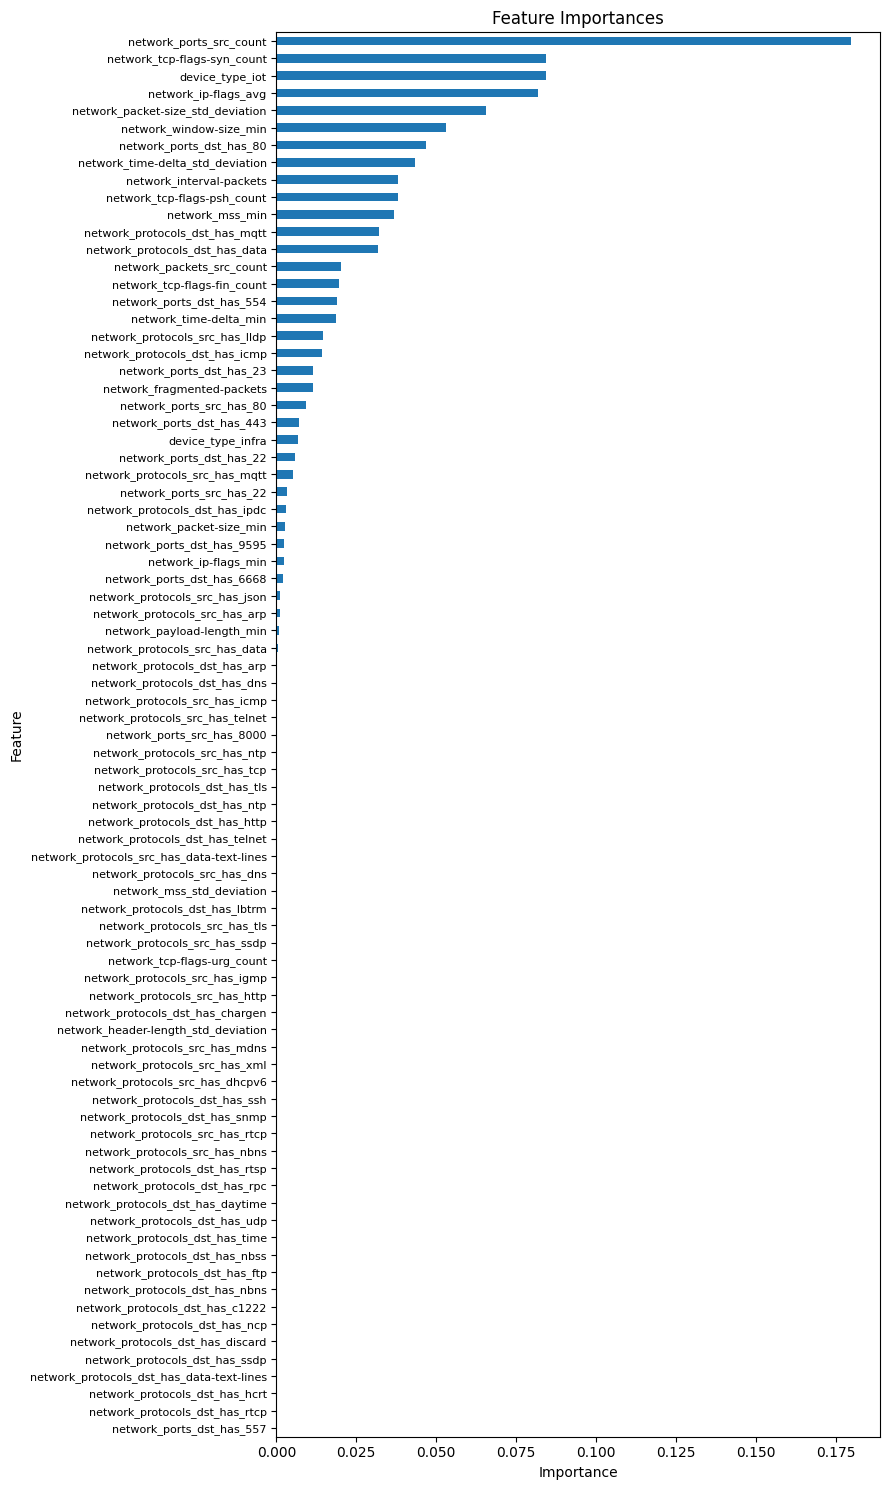

In [10]:
fig, ax = plt.subplots(figsize=(9, 15))

feature_importances["importance"].plot(kind="barh", ax=ax)

ax.invert_yaxis()
ax.set_yticks(
    ticks=range(feature_importances.shape[0]),
    labels=feature_importances["feature"],
    fontsize=8,
)
ax.set_title("Feature Importances")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.savefig(results_dir / "feature_importances.png", dpi=300)
plt.show()

# Model evaluations

## Train-split evaluations

In [11]:
y_proba = trained_pipe.predict_proba(X_train)

train_results = pd.DataFrame(
    data=y_proba,
    columns=trained_pipe.classes_,
    dtype="float32",
)

train_results.to_parquet(
    results_dir / "train_predict_proba.parquet",
    index=False,
    compression="gzip",
)

## Test-split evaluations

In [12]:
y_proba = trained_pipe.predict_proba(X_test)

test_results = pd.DataFrame(
    data=y_proba,
    columns=trained_pipe.classes_,
    dtype="float32",
)

test_results.to_parquet(
    results_dir / "test_predict_proba.parquet",
    index=False,
    compression="gzip",
)

# Model summary and persistency

## Model persistency

In [13]:
pipe_persist_path = results_dir / "pipe.pickle.gz"

with gz_open(pipe_persist_path, mode="wb") as pf:
    Pickler(pf, protocol=5).dump(trained_pipe)

## Model summary

In [14]:
trained_tree = trained_model.tree_

model_summary = {
    "best_parameters": grid.best_params_,
    "all_parameters": trained_model.get_params(),
    "tree_structure": {
        "n_nodes": int(trained_tree.node_count),
        "n_leafs": int(trained_tree.n_leaves),
        "max_depth": int(trained_tree.max_depth),
    }
}

model_summary = dumps(model_summary, indent=2)
(results_dir / "model_summary.json").write_text(model_summary)
print("MODEL SUMMARY:", model_summary, sep="\n")

MODEL SUMMARY:
{
  "best_parameters": {
    "model__criterion": "entropy",
    "model__max_leaf_nodes": null,
    "model__min_samples_leaf": 3
  },
  "all_parameters": {
    "ccp_alpha": 0.0,
    "class_weight": "balanced",
    "criterion": "entropy",
    "max_depth": null,
    "max_features": null,
    "max_leaf_nodes": null,
    "min_impurity_decrease": 0.0,
    "min_samples_leaf": 3,
    "min_samples_split": 2,
    "min_weight_fraction_leaf": 0.0,
    "monotonic_cst": null,
    "random_state": 12345,
    "splitter": "best"
  },
  "tree_structure": {
    "n_nodes": 20171,
    "n_leafs": 10086,
    "max_depth": 47
  }
}
